# Comparison Smoothing

This notebook demonstrates and compares different smoothing techniques for irradiance estimation in optical simulations using the `diffinytrace` package.

It runs locally and is intended for development, analysis, and visualization of how various smoothing kernels affect the accuracy and convergence of irradiance distributions.  
All computations and results are saved to the local filesystem.


In [1]:
import sys
import os

sys.path.insert(0, os.path.abspath(".."))

import diffinytrace as dit
import torch
import numpy as np
torch.set_default_dtype(torch.float64)
import random

SEED = 0
np.random.seed(SEED)
torch.manual_seed(SEED)
random.seed(SEED)


#torch.set_default_device("cuda:0")
device = "cuda:0"
aperture_radius = 12.7
#NBK7 = dit.materials["NBK7"]
#dit.plotting.wavelength.plot(NBK7)

dit_nbk7 = dit.RefractiveIndex(lambda x:1.5046606373973115 + 4215.6909567737075 / (x*1000)**2,[0.1,1.5])
dit_air = dit.RefractiveIndex(lambda x:1.000293,[0.1,1.5])


import os
results_folder = "results/comparison_smoothing/"
try:
    os.mkdir("results")
except:
    pass
try:
    os.mkdir(results_folder)
except:
    pass


In [2]:
n_enviroment = 1.000293
wave_len = 0.5328

lens_pos1D = 0.5
lens_thickness = 6.5
curvature = 0.05
detector_distance = 25.


light_transform = dit.transforms.Offset(torch.tensor([0.0,0.0,0.0]))
light_source = dit.source.CollimatedMonochromatic(light_transform,aperture_radius,wave_len)
light_transform.pos.requires_grad = False

lens_transform = dit.transforms.Distance(lens_pos1D,parent_transform=light_transform)
lens_transform.distance.requires_grad = False
surface1 = dit.Aspheric(curvature=curvature)
surface2 = dit.Plane()
lens1 = dit.Lens(lens_transform,lens_thickness,surface1,surface2,dit_nbk7,aperture_radius)
lens1.lens_thickness.requires_grad = False

detector_transform = dit.transforms.Distance(detector_distance)#25.0+0.5
detector_transform.distance.requires_grad = False
plane_surface = dit.Plane()

det_aperture_radius = aperture_radius*0.5
detector = dit.Detector(detector_transform,plane_surface,det_aperture_radius)

#gridxt = torch.linspace(-aperture_radius,aperture_radius,grid_size)
#grid_delta =gridxt[1]-gridxt[0] 


system = dit.SequentialOpticalSystem({"source":light_source,"lens":lens1,"detector":detector},dit_air)
system = system.to(device)

In [3]:
num_pix = 100
__gridxt = torch.linspace(-det_aperture_radius,det_aperture_radius,num_pix)
print("num_pix",num_pix,"grid_delta",__gridxt[1]-__gridxt[0])


num_pix 100 grid_delta tensor(0.1283)


In [4]:

x,weights = light_source.sample(30)
x = x.to(device)
sequence = ["source","lens","detector"]
O,D,wave_len,_,RayPaths = system(x,sequence)

#dit.plotting.system3D.plot(system,RayPaths,show_grid=False)
#dit.plotting.system2D.plot(system,RayPaths)

100%|██████████| 100/100 [00:03<00:00, 32.56it/s]


<Figure size 640x480 with 0 Axes>

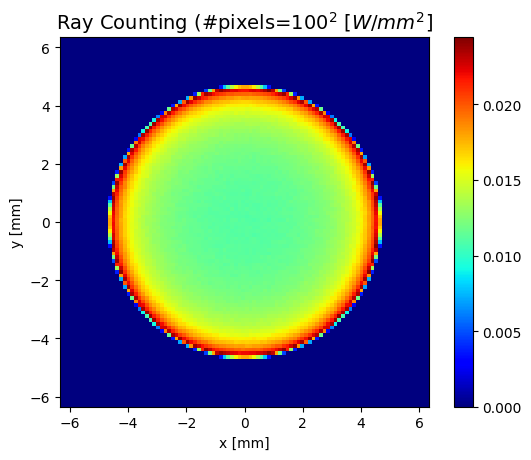

In [5]:
import numpy as np
import torch
import tqdm
from diffinytrace.render import binned_irradiance


grid = dit.target_grid.GridSquare(det_aperture_radius,num_pix)
raycounting_list = []
for k in tqdm.tqdm(range(100)):
    tmp = binned_irradiance(optical_system=system,sequence=sequence,source=light_source,detector=detector,grid=grid,num_rays=1000000,method_ray_tracing="monte_carlo",device=device)
    tmp = tmp.detach().cpu()
    raycounting_list.append(tmp)
raycounting = torch.mean(torch.stack(raycounting_list),dim=0).detach().cpu()


dit.plotting.quantity2D.intensity(raycounting,f"Ray Counting (#pixels=${grid.x_grid_size}^2$",[-det_aperture_radius,det_aperture_radius])



In [6]:
smooth_baseline_dict = {}
sigmas = [0.1,0.3,0.5]

def desired_irradiance_fun(x):
        device = x.device
        dtype = x.dtype
        
        x = torch.clamp(x, min=-det_aperture_radius, max=det_aperture_radius)
        k = grid.get_k(x,round_to_bounds=True)
        k = k.cpu()
        
        out = raycounting.reshape(-1)[k]
        out = out.to(device=device,dtype=dtype)
        return out
    
"""
Here we reuse the implementation of calculating the desired irradiance, to smooth the raycounting result.
"""
dtype = torch.float64
for sigma in tqdm.tqdm(sigmas):

    smoother = dit.gaussian_smoother.GaussianSmootherSquare(det_aperture_radius,num_pix,sigma,desired_irradiance_fun,smoothed_num_integration_points=2**21,smoothed_num_splits=10,device="cpu")
    #.smoothing.GaussianSmootherSquare(det_aperture_radius,num_pix,sigma,device="cpu",desired_irradiance_func=desired_irradiance_func)
    integrator = dit.integrators.Cube([smoother.x_range, smoother.y_range])
        
    with torch.no_grad():
        y,weights = integrator.sample([grid.x_grid_size,grid.y_grid_size],"midpoint")
        y = y.to(device="cpu",dtype=dtype)
        weights = weights.to(device="cpu",dtype=dtype)
        val_multi = desired_irradiance_fun(y)*weights
        tmp_multi = (1./torch.sum(val_multi)).detach().cpu()

        val_multi = val_multi*tmp_multi

        tmp = smoother.smoothed_irradiance(y,val_multi)
        smooth_baseline_dict[sigma] = tmp


100%|██████████| 3/3 [00:08<00:00,  2.96s/it]


In [7]:
np.linspace(0.1,0.5,13)

array([ 0.1       ,  0.13333333,  0.16666667,  0.2       ,  0.23333333,
        0.26666667,  0.3       ,  0.33333333,  0.36666667,  0.4       ,
        0.43333333,  0.46666667,  0.5       ])

In [ ]:
import gc


def render_sigmas_num_rays(num_rays):
    tmp = binned_irradiance(optical_system=system,sequence=sequence,source=light_source,detector=detector,grid=grid,num_rays=num_rays,method_ray_tracing="monte_carlo",device=device)
    tmp = tmp.detach().cpu()
    binned_irradiance_out = tmp

    quick_render = lambda num_rays,smoother: dit.render.smoothed_irradiance(optical_system=system,sequence=sequence,source=light_source,detector=detector,smoother=smoother,num_rays=num_rays,method_ray_tracing="monte_carlo",device=device).cpu()
    get_smoother = lambda sigma: dit.gaussian_smoother.GaussianSmootherSquare(det_aperture_radius,num_pix,sigma,desired_irradiance_fun,smoothed_num_integration_points=2,smoothed_num_splits=1,device="cpu")
    all_smoothed_irr_ = {}


    midcut = 0.1
    num_points_left = 30
    num_points_right = 10 
    all_sigmas = list(np.linspace(1e-3,midcut,num_points_left))+list(np.linspace(midcut,0.5,num_points_right))
    for sigma in tqdm.tqdm(all_sigmas):
        smoother = get_smoother(sigma)
        tmp = quick_render(num_rays,smoother)
        tmp = tmp.detach().cpu()
        all_smoothed_irr_[sigma] = tmp

    gc.collect()
    out = {"binned_irradiance":binned_irradiance_out,"all_smoothed_irr":all_smoothed_irr_}
    return out

plotter_data = {}
for num_rays in [10*1e3,10*1e4,10*1e5,10*1e6]:
    num_rays = int(num_rays)
    plotter_data[num_rays] = render_sigmas_num_rays(num_rays)


  0%|          | 0/40 [00:00<?, ?it/s]

100%|██████████| 40/40 [03:56<00:00,  5.91s/it]


<>:20: SyntaxWarning: invalid escape sequence '\s'
<>:20: SyntaxWarning: invalid escape sequence '\s'
C:\Users\marti\AppData\Local\Temp\ipykernel_13076\3751446745.py:20: SyntaxWarning: invalid escape sequence '\s'
  plt.xlabel('$\sigma$ [mm]')#, fontsize=14


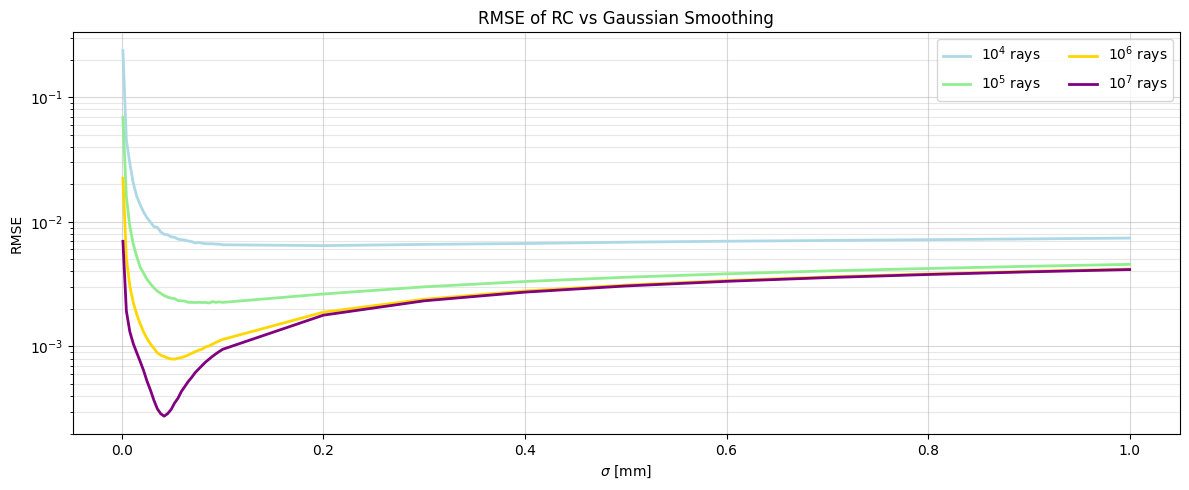

In [ ]:
import matplotlib.pyplot as plt


plt.figure(figsize=(12,5))

colors = ['lightblue', 'lightgreen', 'gold', 'purple']
for i, num_rays_plotter in enumerate(plotter_data.keys()):
    data = plotter_data[num_rays_plotter]
    binned_irradiance_out = data["binned_irradiance"]
    all_smoothed_irr_ = data["all_smoothed_irr"]

    sigmas = np.sort(list(all_smoothed_irr_.keys()))[::-1]
    rmse_fun = lambda irr: torch.sqrt(torch.mean((irr-binned_irradiance_out)**2.0))
    rmse_elems = [rmse_fun(all_smoothed_irr_[sigma]) for sigma in sigmas]

    plt.plot(sigmas, rmse_elems,'-',linewidth=2, markersize=4,color=colors[i],label=f"$10^{int(np.log10(num_rays_plotter))}$ rays",alpha=1)
    

plt.title('RMSE of RC vs Gaussian Smoothing')#fontsize=16
plt.xlabel('$\sigma$ [mm]')#, fontsize=14
plt.ylabel('RMSE')#, fontsize=14
plt.yscale("log")
plt.legend( ncol=2)
plt.grid(True, 'minor',alpha=0.3)
plt.grid(True,alpha=0.5)
plt.tight_layout()
plt.savefig(results_folder+"convergence_smoothing_to_binned_L".png", dpi=400, bbox_inches='tight')

In [57]:
from torchmetrics.image import StructuralSimilarityIndexMeasure
#pip install torchmetrics

<>:35: SyntaxWarning: invalid escape sequence '\s'
<>:35: SyntaxWarning: invalid escape sequence '\s'
C:\Users\marti\AppData\Local\Temp\ipykernel_13076\296453482.py:35: SyntaxWarning: invalid escape sequence '\s'
  plt.xlabel('$\sigma$ [mm]')#, fontsize=14


0.07009973610139868


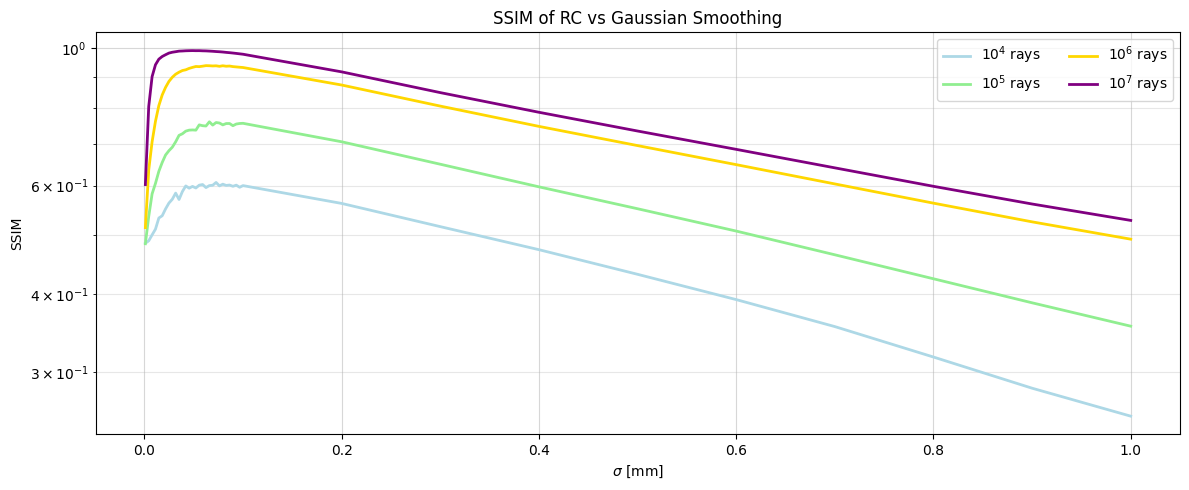

In [74]:
import matplotlib.pyplot as plt


plt.figure(figsize=(12,5))
vmax = 0.
for elem in plotter_data.keys():
    data = plotter_data[num_rays_plotter]
    binned_irradiance_out = data["binned_irradiance"]
    all_smoothed_irr_ = data["all_smoothed_irr"]
    sigmas = np.sort(list(all_smoothed_irr_.keys()))[::-1]
    vmax = max(vmax,torch.max(binned_irradiance_out).item())
    for sigma in sigmas:
        vmax = max(vmax,torch.max(all_smoothed_irr_[sigma]).item())

ssim = StructuralSimilarityIndexMeasure(data_range=vmax)
colors = ['lightblue', 'lightgreen', 'gold', 'purple']
min_sigmas = {}
for i, num_rays_plotter in enumerate(plotter_data.keys()):
    data = plotter_data[num_rays_plotter]
    binned_irradiance_out = data["binned_irradiance"]
    all_smoothed_irr_ = data["all_smoothed_irr"]

    sigmas = np.sort(list(all_smoothed_irr_.keys()))[::-1]
    rmse_fun = lambda irr: ssim(irr[None][None], binned_irradiance_out[None][None])
    rmse_elems = [rmse_fun(all_smoothed_irr_[sigma]) for sigma in sigmas]

    plt.plot(sigmas, rmse_elems,'-',linewidth=2, markersize=4,color=colors[i],label=f"$10^{int(np.log10(num_rays_plotter))}$ rays",alpha=1)
    min_sigmas[np.min(rmse_elems)] = sigmas[np.argmin(rmse_elems)]


#plt.scatter(list(min_sigmas.values()),list(min_sigmas.keys()),color="red",label="Minimum RMSE",s=100,marker=".",zorder=10)


plt.title('SSIM of RC vs Gaussian Smoothing')#fontsize=16
plt.xlabel('$\sigma$ [mm]')#, fontsize=14
plt.ylabel('SSIM')#, fontsize=14
plt.yscale("log")
plt.legend( ncol=2)
plt.grid(True, 'minor',alpha=0.3)
plt.grid(True,alpha=0.5)
plt.tight_layout()
plt.savefig(results_folder+"convergence_smoothing_to_binned_ssim.png", dpi=400, bbox_inches='tight')
print(vmax)

In [49]:
import gc

tmp = binned_irradiance(optical_system=system,sequence=sequence,source=light_source,detector=detector,grid=grid,num_rays=100000,method_ray_tracing="monte_carlo",device=device)
tmp = tmp.detach().cpu()
binned_irradiance_100k = tmp

quick_render = lambda num_rays,smoother: dit.render.smoothed_irradiance(optical_system=system,sequence=sequence,source=light_source,detector=detector,smoother=smoother,num_rays=num_rays,method_ray_tracing="monte_carlo",device=device).cpu()
get_smoother = lambda sigma: dit.gaussian_smoother.GaussianSmootherSquare(det_aperture_radius,num_pix,sigma,desired_irradiance_fun,smoothed_num_integration_points=2**21,smoothed_num_splits=10,device="cpu")
all_smoothed_irr100k = []
for sigma in tqdm.tqdm([0.1,0.2,0.5]):
    smoother = get_smoother(sigma)
    tmp = quick_render(100000,smoother)
    tmp = tmp.detach().cpu()
    all_smoothed_irr100k.append(tmp)

gc.collect()


100%|██████████| 3/3 [00:10<00:00,  3.59s/it]


0

C:\Users\marti\AppData\Local\Temp\ipykernel_19316\1786800411.py:49: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  np.array(img)[::-1],


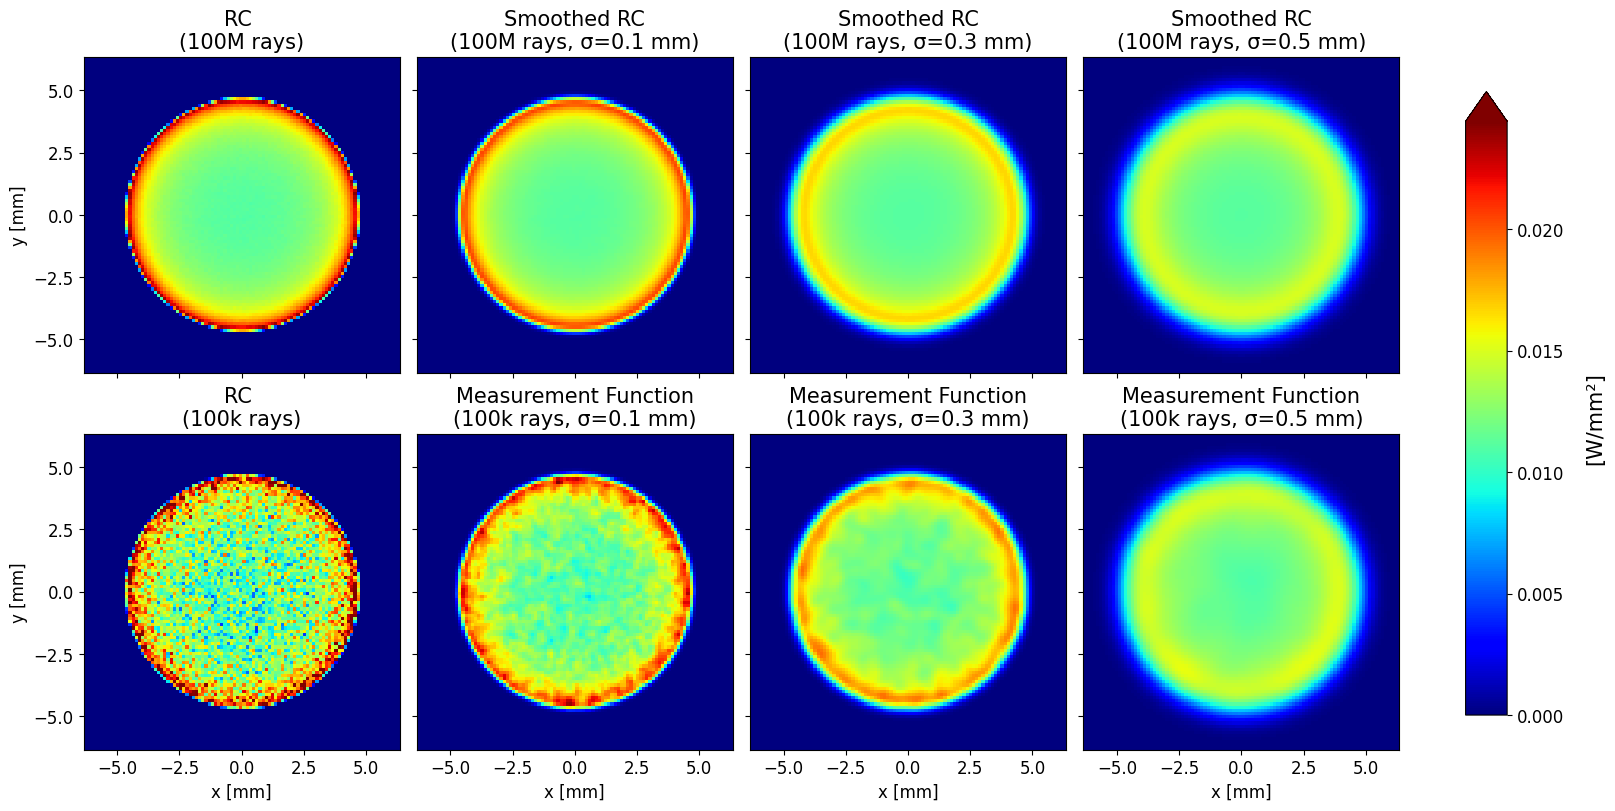

In [13]:
import matplotlib.pyplot as plt
import torch
##raycounting_high
smooth_baseline_dict = {key: val.cpu() for key, val in smooth_baseline_dict.items()}
binned_irradiance_100k = binned_irradiance_100k.cpu()
all_smoothed_irr100k = [tmp.cpu() for tmp in all_smoothed_irr100k]
raycounting = raycounting.cpu()
# Example placeholders (replace with your data)
irrs = [raycounting] + [val for val in smooth_baseline_dict.values()]+[binned_irradiance_100k]+all_smoothed_irr100k
irrs = [irr.cpu() for irr in irrs]

rows_extent = [[-det_aperture_radius, det_aperture_radius,
                 -det_aperture_radius, det_aperture_radius]] * len(irrs)
# sigmas = [...]

cbar_labelsize = 12
cbar_title_fontsize = 15
cmap = "jet"
cbar_title = "[W/mm²]"


# Compute common vmin/vmax
vmin = 0#torch.min(torch.cat(irrs + [raycounting_high.cpu()]))
vmax = torch.max(torch.cat([raycounting] + list(smooth_baseline_dict.values())+all_smoothed_irr100k))

# Create 2×4 grid, plus an extra column for the shared colorbar
fig, axes = plt.subplots(
    nrows=2, ncols=4, figsize=(16, 8),
    constrained_layout=True
)

# Titles for each column
columns_title = (
    ["RC \n(100M rays)"] +
    [f"Smoothed RC\n(100M rays, σ={sigma} mm)" for sigma in sigmas] +
    ["RC \n(100k rays)"] +
    [f"Measurement Function\n(100k rays, σ={sigma} mm)" for sigma in sigmas]
)

# Flatten axes for easy iteration
axes = axes.flatten()

# Plot each irradiance map
ims = []
for k, ax in enumerate(axes):
    if k < len(irrs):
        img = irrs[k]
        im = ax.imshow(
            np.array(img)[::-1],
            extent=rows_extent[k],
            vmin=vmin, vmax=vmax,
            origin='lower', cmap=cmap
        )
        ims.append(im)
        ax.set_title(columns_title[k], fontsize=cbar_title_fontsize)
        ax.set_xticks([-5, -2.5, 0, 2.5, 5])
        ax.set_yticks([-5, -2.5, 0, 2.5, 5])
        ax.tick_params(labelsize=cbar_labelsize)
        if k < 4:
            if k == 0:
                ax.tick_params(labelbottom=False)
                ax.set_ylabel("y [mm]", fontsize=cbar_labelsize)  # Add ylabel
            else:
                ax.tick_params(labelbottom=False, labelleft=False)
        else:
            if k == 4:
                ax.set_ylabel("y [mm]", fontsize=cbar_labelsize)  # Add ylabel
                ax.set_xlabel("x [mm]", fontsize=cbar_labelsize)  # Add ylabel
            else:
                ax.tick_params(labelleft=False)
                ax.set_xlabel("x [mm]", fontsize=cbar_labelsize)  # Add ylabel

    else:
        ax.axis("off")  # Hide unused subplot if fewer than 8 maps

# Add ONE big colorbar on the right
cbar = fig.colorbar(
    ims[0], ax=axes, shrink=0.9, aspect=15,extend='max'   # smaller aspect → thicker bar
)

# Tick labels
cbar.ax.tick_params(labelsize=cbar_labelsize)

# Set label centered along the bar
cbar.set_label(cbar_title, fontsize=cbar_title_fontsize, labelpad=15)

# Offset text (scientific notation scale) adjustments
offset_text = cbar.ax.yaxis.offsetText
offset_text.set_size(cbar_labelsize)
offset_text.set_ha('left')
plt.savefig(results_folder+"irradiance_image_overviewA.png", dpi=400, bbox_inches='tight')

plt.show()


C:\Users\marti\AppData\Local\Temp\ipykernel_19316\1181717374.py:46: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  np.array(img)[::-1],


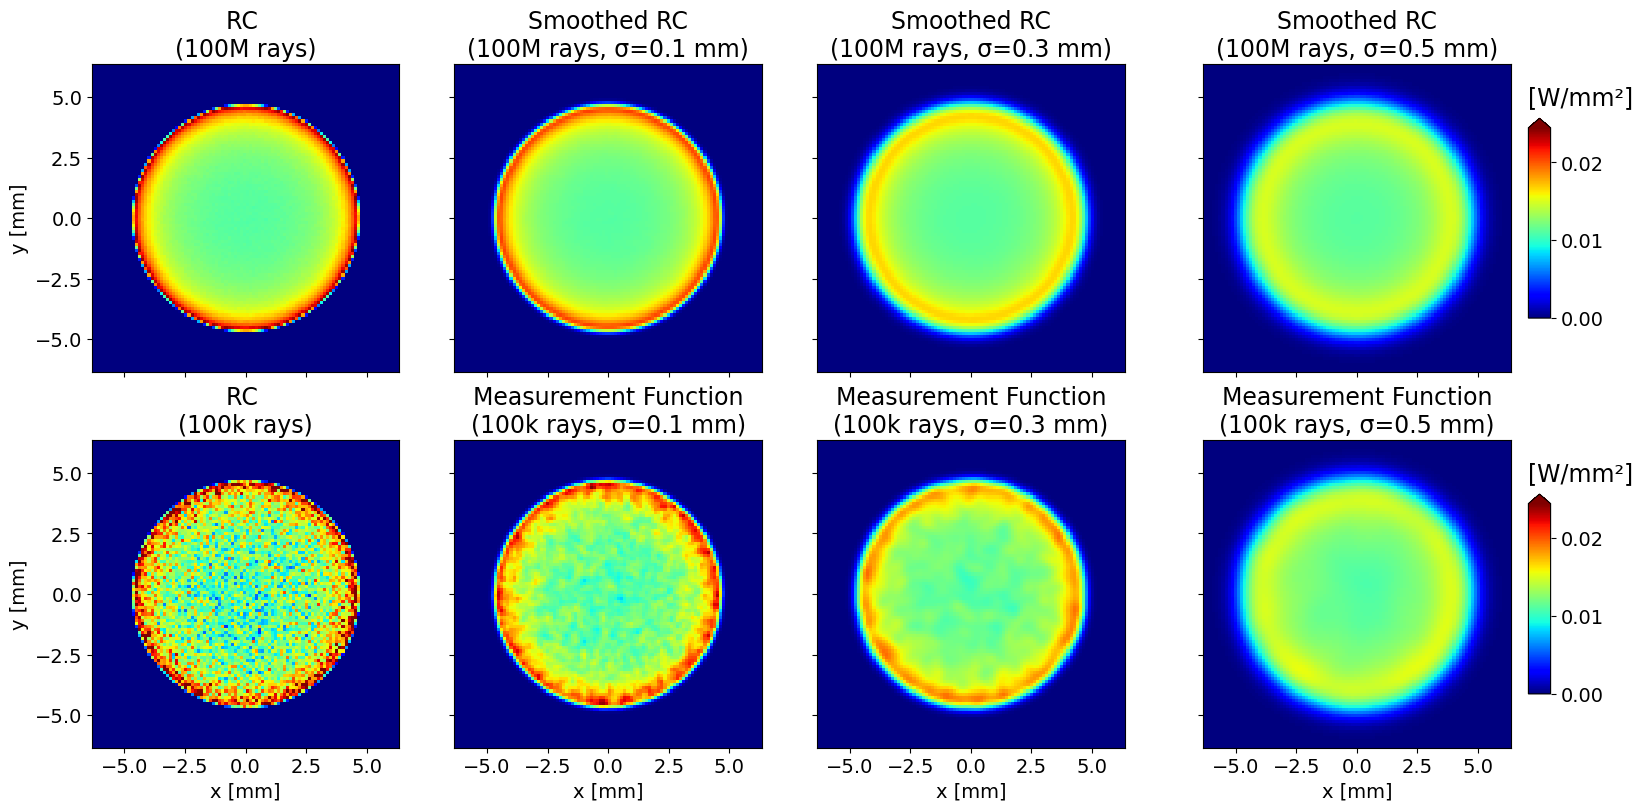

In [14]:
import matplotlib.pyplot as plt
import torch
##raycounting_high

# Example placeholders (replace with your data)
irrs = [raycounting] + [val for val in smooth_baseline_dict.values()]+[binned_irradiance_100k]+all_smoothed_irr100k
irrs = [irr.cpu() for irr in irrs]

rows_extent = [[-det_aperture_radius, det_aperture_radius,
                 -det_aperture_radius, det_aperture_radius]] * len(irrs)
# sigmas = [...]

cbar_labelsize = 14
cbar_title_fontsize = 17
cmap = "jet"
cbar_title = "[W/mm²]"


# Compute common vmin/vmax
vmin = 0#torch.min(torch.cat(irrs + [raycounting_high.cpu()]))
vmax = torch.max(torch.cat([raycounting] + list(smooth_baseline_dict.values())+all_smoothed_irr100k))

# Create 2×4 grid, plus an extra column for the shared colorbar
fig, axes = plt.subplots(
    nrows=2, ncols=4, figsize=(16, 8),
    constrained_layout=True
)

# Titles for each column
columns_title = (
    ["RC \n(100M rays)"] +
    [f"Smoothed RC\n(100M rays, σ={sigma} mm)" for sigma in sigmas] +
    ["RC \n(100k rays)"] +
    [f"Measurement Function\n(100k rays, σ={sigma} mm)" for sigma in sigmas]
)

# Flatten axes for easy iteration
axes = axes.flatten()

# Plot each irradiance map
ims = []
for k, ax in enumerate(axes):
    if k < len(irrs):
        img = irrs[k]
        im = ax.imshow(
            np.array(img)[::-1],
            extent=rows_extent[k],
            vmin=vmin, vmax=vmax,
            origin='lower', cmap=cmap
        )
        ims.append(im)
        ax.set_title(columns_title[k], fontsize=cbar_title_fontsize)
        ax.set_xticks([-5, -2.5, 0, 2.5, 5])
        ax.set_yticks([-5, -2.5, 0, 2.5, 5])
        ax.tick_params(labelsize=cbar_labelsize)
        if k < 4:
            if k == 0:
                ax.tick_params(labelbottom=False)
                ax.set_ylabel("y [mm]", fontsize=cbar_labelsize)  # Add ylabel
            else:
                ax.tick_params(labelbottom=False, labelleft=False)
        else:
            if k == 4:
                ax.set_ylabel("y [mm]", fontsize=cbar_labelsize)  # Add ylabel
                ax.set_xlabel("x [mm]", fontsize=cbar_labelsize)  # Add ylabel
            else:
                ax.tick_params(labelleft=False)
                ax.set_xlabel("x [mm]", fontsize=cbar_labelsize)  # Add ylabel
        if k == 3 or k == 7:
            cbar = plt.colorbar(im,ax=ax,shrink=0.65,aspect=9,extend='max') # Add a colorbar for reference
            cbar.ax.tick_params(labelsize=cbar_labelsize)
            cbar.ax.set_title("[W/mm²]", fontsize=cbar_title_fontsize, pad=10,loc="left") # Set label above
    else:
        ax.axis("off")  # Hide unused subplot if fewer than 8 maps

"""# Add ONE big colorbar on the right
cbar = fig.colorbar(
    ims[0], ax=axes, shrink=0.9, aspect=15,extend='max'   # smaller aspect → thicker bar
)

# Tick labels
cbar.ax.tick_params(labelsize=cbar_labelsize)

# Set label centered along the bar
cbar.set_label(cbar_title, fontsize=cbar_title_fontsize, labelpad=15)

# Offset text (scientific notation scale) adjustments
offset_text = cbar.ax.yaxis.offsetText
offset_text.set_size(cbar_labelsize)
offset_text.set_ha('left')
"""
plt.savefig(results_folder+"irradiance_image_overviewA2.png", dpi=400, bbox_inches='tight')

plt.show()


In [ ]:
import tqdm
import gc
def run_all_simulations():
    
    vmax = 0.
    
    global smoother_baseline_irrs
    
    L2_diff_RC = {}
    L2_diff_smooth = {}

    RMSE_RC = {}
    RMSE_smooth = {}
    #2**np.linspace(8,20,20)
    all_num_rays = np.array(2**np.linspace(5,20,50),dtype=np.int64)
    #,5000,10000

    RMSE_RC_RC = []
    for num_rays in tqdm.tqdm(all_num_rays):
            
        irr = binned_irradiance(optical_system=system,sequence=sequence,source=light_source,detector=detector,grid=grid,num_rays=num_rays,method_ray_tracing="monte_carlo",device=device).cpu()
            
        #_L2_diff_RC = torch.sqrt(smoother.get_integral_over_distribution((irr-raycounting)**2.0))
        vmax = max(vmax,torch.max(irr).item())
        vmax = max(vmax,torch.max(raycounting).item())

        _RMSE_RC = torch.sqrt(torch.mean((irr-raycounting)**2.0))
            
        RMSE_RC_RC.append(_RMSE_RC)
            
        #L2_diff_RC[sigma].append(_L2_diff_RC)
        
    for sigma in sigmas:
        quick_render = lambda num_rays,smoother: dit.render.smoothed_irradiance(optical_system=system,sequence=sequence,source=light_source,detector=detector,smoother=smoother,num_rays=num_rays,method_ray_tracing="monte_carlo",device=device).cpu()
        get_smoother = lambda sigma: dit.gaussian_smoother.GaussianSmootherSquare(det_aperture_radius,num_pix,sigma,desired_irradiance_fun,smoothed_num_integration_points=2**21,smoothed_num_splits=10,device="cpu")
        smoother = get_smoother(sigma)
        
        baseline_smooth_irr = smooth_baseline_dict[sigma]
        
        vmax = max(vmax,torch.max(baseline_smooth_irr).item())

        RMSE_RC[sigma] = []
        RMSE_smooth[sigma] = []
        
        L2_diff_RC[sigma] = []
        L2_diff_smooth[sigma] = []
        

        for num_rays in tqdm.tqdm(all_num_rays):
            gc.collect()
            #print("after baseline render")
            
            irr = quick_render(num_rays,smoother)
            vmax = max(vmax,torch.max(irr).item())
                
            _L2_diff_RC = torch.sqrt(smoother.integrate_values((irr-raycounting)**2.0))
            _L2_diff_smooth = torch.sqrt(smoother.integrate_values((irr-baseline_smooth_irr)**2.0))
            

            _RMSE_RC = torch.sqrt(torch.mean((irr-raycounting)**2.0))
            _RMSE_smooth = torch.sqrt(torch.mean((irr-baseline_smooth_irr)**2.0))
            
            RMSE_RC[sigma].append(_RMSE_RC)
            RMSE_smooth[sigma].append(_RMSE_smooth)
            
            L2_diff_RC[sigma].append(_L2_diff_RC)
            L2_diff_smooth[sigma].append(_L2_diff_smooth)
    
    
    ssim = StructuralSimilarityIndexMeasure(data_range=vmax)
    

    return RMSE_RC, RMSE_smooth, L2_diff_RC, L2_diff_smooth,RMSE_RC_RC,all_num_rays

In [16]:
import matplotlib.pyplot as plt
import torch
import numpy as np


gc.collect()
RMSE_RC, RMSE_smooth, L2_diff_RC, L2_diff_smooth,RMSE_RC_RC,all_num_rays = run_all_simulations()
# Get the number of different ray counts


100%|██████████| 50/50 [00:08<00:00,  6.01it/s]


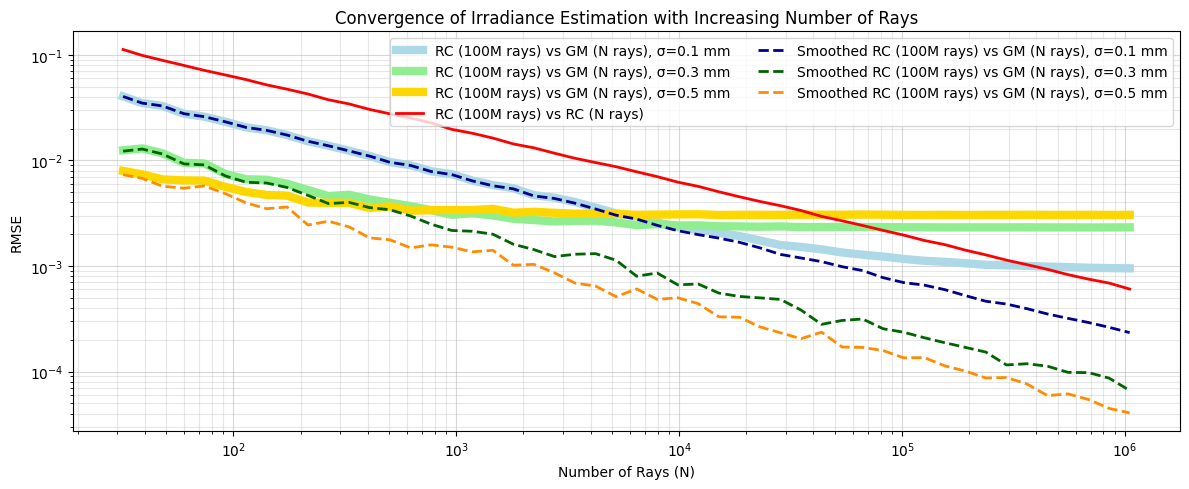

In [17]:
import matplotlib.pyplot as plt


plt.figure(figsize=(12,5))

colors = ['lightblue', 'lightgreen', 'gold', 'purple']
for i, sigma in enumerate(RMSE_RC.keys()):
    plt.loglog(all_num_rays,[elem.cpu() for elem in RMSE_RC[sigma]],'-',linewidth=6, markersize=4,color=colors[i],label=f"RC (100M rays) vs GM (N rays), σ={sigma} mm",alpha=1)
    
plt.loglog(all_num_rays,[elem.cpu() for elem in RMSE_RC_RC],linewidth=2, markersize=4,color ="red",label="RC (100M rays) vs RC (N rays)")
colors = ['darkblue', 'darkgreen', 'darkorange', 'purple']
for i, sigma in enumerate(RMSE_RC.keys()):
    plt.loglog(all_num_rays,[elem.cpu() for elem in RMSE_smooth[sigma]],'--',linewidth=2, markersize=4,color = colors[i],label=f"Smoothed RC (100M rays) vs GM (N rays), σ={sigma} mm", alpha=1)


plt.title('Convergence of Irradiance Estimation with Increasing Number of Rays')#fontsize=16
plt.xlabel('Number of Rays (N)')#, fontsize=14
plt.ylabel('RMSE')#, fontsize=14
plt.legend( ncol=2)
plt.grid(True, 'minor',alpha=0.3)
plt.grid(True,alpha=0.5)
plt.tight_layout()
plt.savefig(results_folder+"irradiance_comparison_RMSE_VA.png", dpi=400, bbox_inches='tight')
        

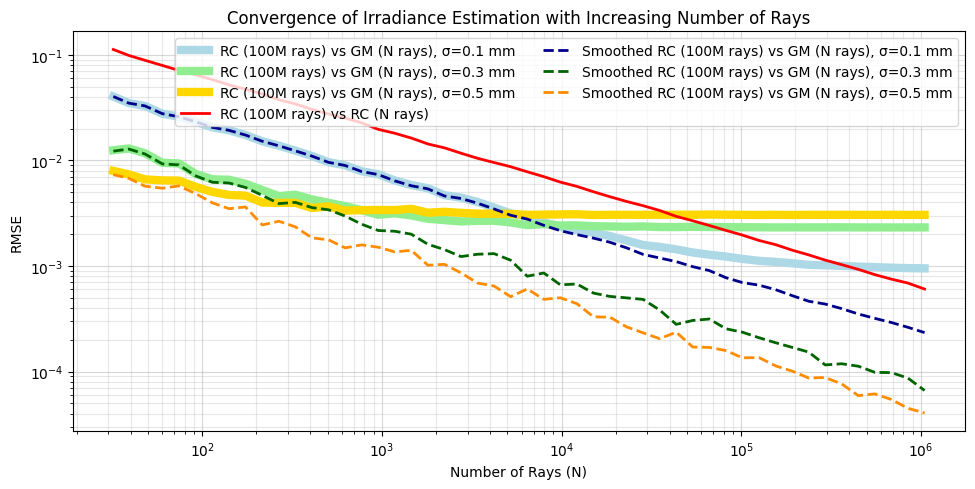

In [18]:
import matplotlib.pyplot as plt


plt.figure(figsize=(10,5))

colors = ['lightblue', 'lightgreen', 'gold', 'purple']
for i, sigma in enumerate(RMSE_RC.keys()):
    plt.loglog(all_num_rays,[elem.cpu() for elem in RMSE_RC[sigma]],'-',linewidth=6, markersize=4,color=colors[i],label=f"RC (100M rays) vs GM (N rays), σ={sigma} mm",alpha=1)
    
plt.loglog(all_num_rays,[elem.cpu() for elem in RMSE_RC_RC],linewidth=2, markersize=4,color ="red",label="RC (100M rays) vs RC (N rays)")
colors = ['darkblue', 'darkgreen', 'darkorange', 'purple']
for i, sigma in enumerate(RMSE_RC.keys()):
    plt.loglog(all_num_rays,[elem.cpu() for elem in RMSE_smooth[sigma]],'--',linewidth=2, markersize=4,color = colors[i],label=f"Smoothed RC (100M rays) vs GM (N rays), σ={sigma} mm", alpha=1)


plt.title('Convergence of Irradiance Estimation with Increasing Number of Rays')#fontsize=16
plt.xlabel('Number of Rays (N)')#, fontsize=14
plt.ylabel('RMSE')#, fontsize=14
plt.legend( ncol=2)
plt.grid(True, 'minor',alpha=0.3)
plt.grid(True,alpha=0.5)
plt.tight_layout()
plt.savefig(results_folder+"irradiance_comparison_RMSE_VB.png", dpi=400, bbox_inches='tight')


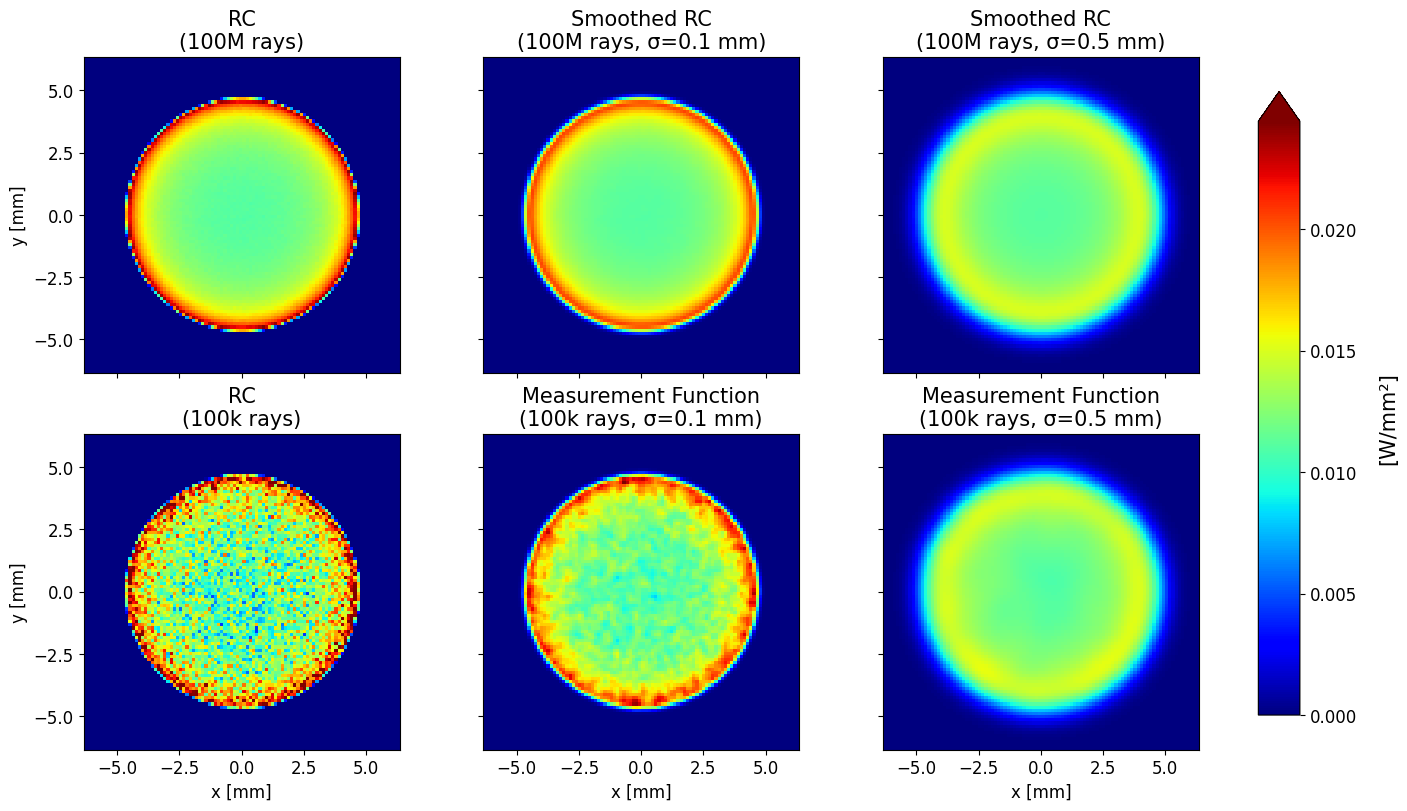

In [19]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import torch


# Prepare data (right-hand grid only)
irrs = [raycounting] + list(smooth_baseline_dict.values()) + [binned_irradiance_100k] + all_smoothed_irr100k
irrs = [irr.cpu() for irr in irrs]

rows_extent = [[
    -det_aperture_radius, det_aperture_radius,
    -det_aperture_radius, det_aperture_radius
]] * len(irrs)

cbar_labelsize = 12
cbar_title_fontsize = 15
cmap = "jet"
cbar_title = "[W/mm²]"

# Color scale across the plotted images
vmin = 0.0
vmax = torch.max(torch.cat([raycounting] + list(smooth_baseline_dict.values())+all_smoothed_irr100k))

# Figure layout: 2 rows × 3 cols
fig = plt.figure(figsize=(14, 8), constrained_layout=True)
gs = gridspec.GridSpec(2, 3, figure=fig)

# Titles corresponding to `irrs`
columns_title = (
    ["RC\n(100M rays)"] +
    [f"Smoothed RC\n(100M rays, σ={sigma} mm)" for sigma in sigmas] +
    ["RC\n(100k rays)"] +
    [f"Measurement Function\n(100k rays, σ={sigma} mm)" for sigma in sigmas]
)

# Remove 3rd and 7th images (0-based indices: 2 and 6)
remove_indices = {2, 6}
irrs        = [irr  for i, irr  in enumerate(irrs)         if i not in remove_indices]
rows_extent = [ext  for i, ext  in enumerate(rows_extent)  if i not in remove_indices]
columns_title = [t for i, t in enumerate(columns_title)    if i not in remove_indices]

# Plot the 2×3 grid
axes = []
ims = []
for r in range(2):
    for c in range(3):
        idx = r * 3 + c
        ax = fig.add_subplot(gs[r, c])
        if idx < len(irrs):
            img = np.array(irrs)[idx]
            im = ax.imshow(
                img[::-1],
                extent=rows_extent[idx],
                vmin=vmin, vmax=vmax,
                origin='lower', cmap=cmap
            )
            ims.append(im)
            axes.append(ax)

            ax.set_title(columns_title[idx], fontsize=cbar_title_fontsize)
            ax.set_xticks([-5, -2.5, 0, 2.5, 5])
            ax.set_yticks([-5, -2.5, 0, 2.5, 5])
            ax.tick_params(labelsize=cbar_labelsize)
            
            # Clean ticks: hide duplicate left labels and top-row bottom labels
            if c != 0:
                ax.tick_params(labelleft=False)
            else:
                ax.set_ylabel("y [mm]", fontsize=cbar_labelsize)  # Add ylabel
        
            if r == 0:
                ax.tick_params(labelbottom=False)
            else:
                ax.set_xlabel("x [mm]", fontsize=cbar_labelsize)  # Add ylabel
        
            
        else:
            ax.axis("off")

# Shared colorbar for everything (thicker, center label, extend at max)
mappable = ims[0]  # there should be at least one image
cbar = fig.colorbar(
    mappable,
    ax=axes,
    shrink=0.9,
    aspect=15,
    extend='max',
)
cbar.ax.tick_params(labelsize=cbar_labelsize)
cbar.set_label(cbar_title, fontsize=cbar_title_fontsize, labelpad=15)

offset_text = cbar.ax.yaxis.offsetText
offset_text.set_size(cbar_labelsize)
offset_text.set_ha('left')

plt.savefig(results_folder + "irradiance_image_overviewD.png",
            dpi=400, bbox_inches='tight')
plt.show()


In [20]:
"""import matplotlib.pyplot as plt
import torch

# --- Assume these are already defined ---
# raycounting_high, det_aperture_radius, vmin, vmax, cmap,
# cbar_labelsize, cbar_title_fontsize, cbar_title

fig, ax = plt.subplots(figsize=(6, 6))  # single square plot

im = ax.imshow(
    raycounting_high.cpu(),
    extent=[-det_aperture_radius, det_aperture_radius,
            -det_aperture_radius, det_aperture_radius],
    vmin=vmin, vmax=vmax,
    origin='lower', cmap=cmap
)

ax.set_title("RC High-Resolution\n(100M rays, $1000^2$ pixels)",
             fontsize=cbar_title_fontsize)
ax.set_xticks([-5, -2.5, 0, 2.5, 5])
ax.set_yticks([-5, -2.5, 0, 2.5, 5])
ax.tick_params(labelsize=cbar_labelsize)

# Optional: add colorbar
cbar = fig.colorbar(im, ax=ax, shrink=0.8, aspect=15,extend='max')
cbar.ax.tick_params(labelsize=cbar_labelsize)
cbar.set_label(cbar_title, fontsize=cbar_title_fontsize, labelpad=15)
plt.savefig(results_folder + "irradiance_image_overviewE.png",
            dpi=400, bbox_inches='tight')

plt.show()
"""

'import matplotlib.pyplot as plt\nimport torch\n\n# --- Assume these are already defined ---\n# raycounting_high, det_aperture_radius, vmin, vmax, cmap,\n# cbar_labelsize, cbar_title_fontsize, cbar_title\n\nfig, ax = plt.subplots(figsize=(6, 6))  # single square plot\n\nim = ax.imshow(\n    raycounting_high.cpu(),\n    extent=[-det_aperture_radius, det_aperture_radius,\n            -det_aperture_radius, det_aperture_radius],\n    vmin=vmin, vmax=vmax,\n    origin=\'lower\', cmap=cmap\n)\n\nax.set_title("RC High-Resolution\n(100M rays, $1000^2$ pixels)",\n             fontsize=cbar_title_fontsize)\nax.set_xticks([-5, -2.5, 0, 2.5, 5])\nax.set_yticks([-5, -2.5, 0, 2.5, 5])\nax.tick_params(labelsize=cbar_labelsize)\n\n# Optional: add colorbar\ncbar = fig.colorbar(im, ax=ax, shrink=0.8, aspect=15,extend=\'max\')\ncbar.ax.tick_params(labelsize=cbar_labelsize)\ncbar.set_label(cbar_title, fontsize=cbar_title_fontsize, labelpad=15)\nplt.savefig(results_folder + "irradiance_image_overviewE.png"

In [21]:
gc.collect()

88442

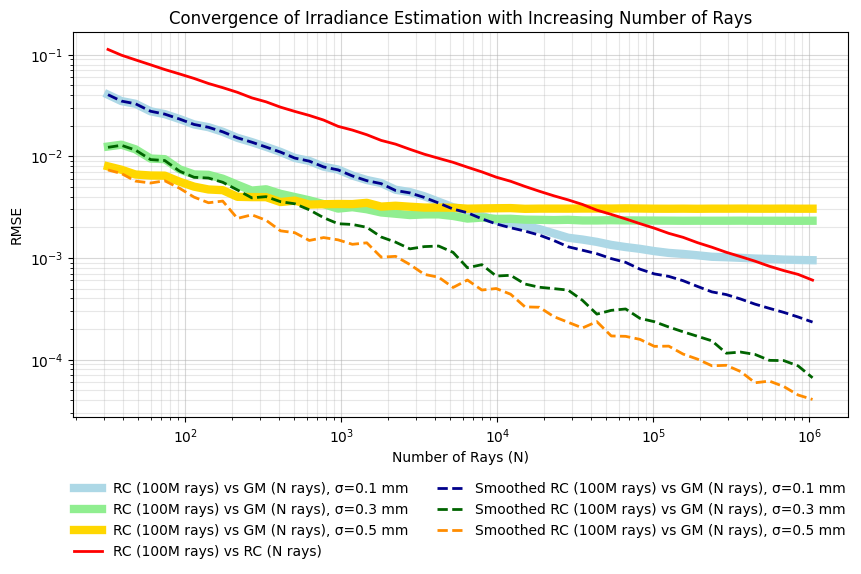

In [22]:
import matplotlib.pyplot as plt


plt.figure(figsize=(10,5))

colors = ['lightblue', 'lightgreen', 'gold', 'purple']
for i, sigma in enumerate(RMSE_RC.keys()):
    plt.loglog(all_num_rays,[elem.cpu() for elem in RMSE_RC[sigma]],'-',linewidth=6, markersize=4,color=colors[i],label=f"RC (100M rays) vs GM (N rays), σ={sigma} mm",alpha=1)
    
plt.loglog(all_num_rays,[elem.cpu() for elem in RMSE_RC_RC],linewidth=2, markersize=4,color ="red",label="RC (100M rays) vs RC (N rays)")
colors = ['darkblue', 'darkgreen', 'darkorange', 'purple']
for i, sigma in enumerate(RMSE_RC.keys()):
    plt.loglog(all_num_rays,[elem.cpu() for elem in RMSE_smooth[sigma]],'--',linewidth=2, markersize=4,color = colors[i],label=f"Smoothed RC (100M rays) vs GM (N rays), σ={sigma} mm", alpha=1)


plt.title('Convergence of Irradiance Estimation with Increasing Number of Rays')#fontsize=16
plt.xlabel('Number of Rays (N)')#, fontsize=14
plt.ylabel('RMSE')#, fontsize=14
plt.legend(ncol=2, loc='lower center', bbox_to_anchor=(0.5, -0.4), frameon=False)
plt.grid(True, 'minor', alpha=0.3)
plt.grid(True, alpha=0.5)
#plt.tight_layout()
plt.savefig(results_folder+"irradiance_comparison_RMSE_VB2.png", dpi=400, bbox_inches='tight')


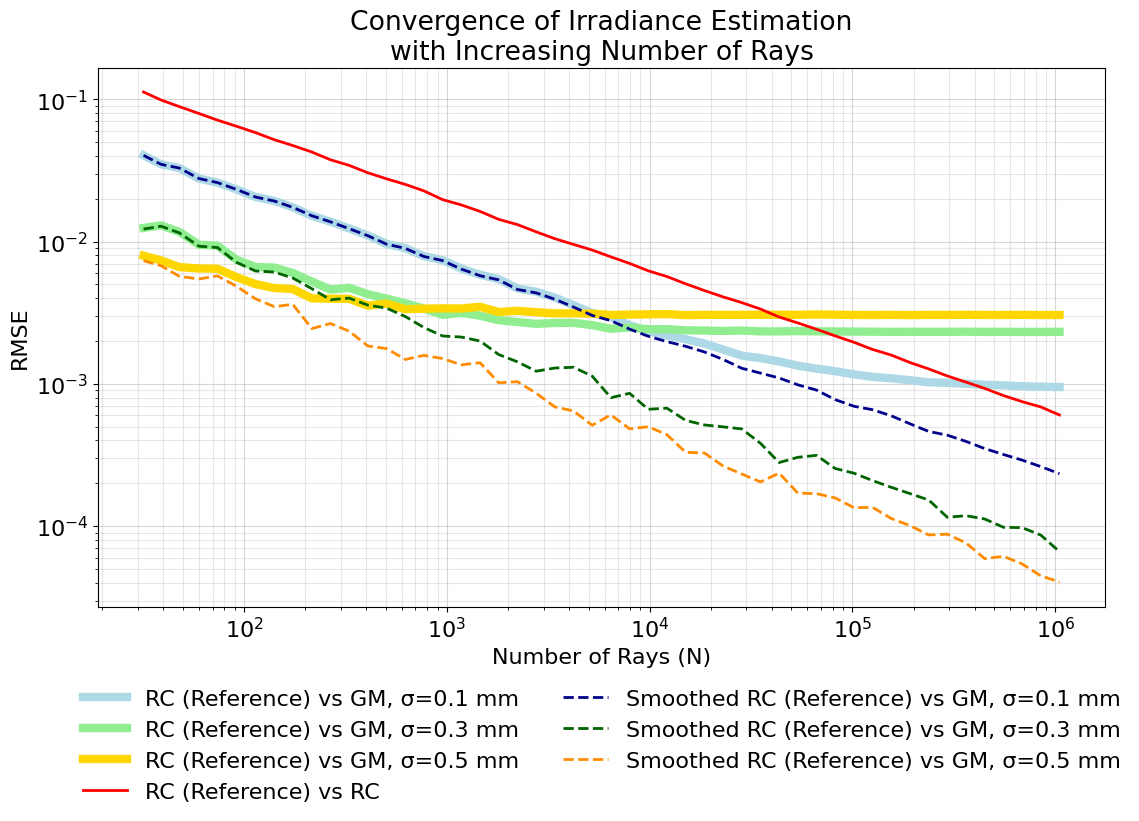

In [23]:
import matplotlib.pyplot as plt


label_font_size = 16
title_font_size = 16
plt.figure(figsize=(13,7))

colors = ['lightblue', 'lightgreen', 'gold', 'purple']
for i, sigma in enumerate(RMSE_RC.keys()):
    plt.loglog(all_num_rays,[elem.cpu() for elem in RMSE_RC[sigma]],'-',linewidth=6, markersize=4,color=colors[i],label=f"RC (Reference) vs GM, σ={sigma} mm",alpha=1)
    
plt.loglog(all_num_rays,[elem.cpu() for elem in RMSE_RC_RC],linewidth=2, markersize=4,color ="red",label="RC (Reference) vs RC")
colors = ['darkblue', 'darkgreen', 'darkorange', 'purple']
for i, sigma in enumerate(RMSE_RC.keys()):
    plt.loglog(all_num_rays,[elem.cpu() for elem in RMSE_smooth[sigma]],'--',linewidth=2, markersize=4,color = colors[i],label=f"Smoothed RC (Reference) vs GM, σ={sigma} mm", alpha=1)


plt.title('Convergence of Irradiance Estimation\nwith Increasing Number of Rays', fontsize=title_font_size*1.2)
plt.xlabel('Number of Rays (N)', fontsize=label_font_size)
plt.ylabel('RMSE', fontsize=label_font_size)
plt.tick_params(axis='both', labelsize=label_font_size)  # <-- Increase tick font size
plt.legend(ncol=2, loc='lower center', bbox_to_anchor=(0.5, -0.4), frameon=False, fontsize=title_font_size)
plt.grid(True, 'minor', alpha=0.3)
plt.grid(True, alpha=0.5)
#plt.tight_layout()
plt.savefig(results_folder+"irradiance_comparison_RMSE_VB3.png", dpi=400, bbox_inches='tight')
